In [1]:
import numpy as np

def compute_det_curve(target_scores, nontarget_scores):

    n_scores = target_scores.size + nontarget_scores.size
    all_scores = np.concatenate((target_scores, nontarget_scores))
    labels = np.concatenate((np.ones(target_scores.size), np.zeros(nontarget_scores.size)))

    # Sort labels based on scores
    indices = np.argsort(all_scores, kind='mergesort')
    labels = labels[indices]

    # Compute false rejection and false acceptance rates
    tar_trial_sums = np.cumsum(labels)
    nontarget_trial_sums = nontarget_scores.size - (np.arange(1, n_scores + 1) - tar_trial_sums)

    frr = np.concatenate((np.atleast_1d(0), tar_trial_sums / target_scores.size))  # false rejection rates
    far = np.concatenate((np.atleast_1d(1), nontarget_trial_sums / nontarget_scores.size))  # false acceptance rates
    thresholds = np.concatenate((np.atleast_1d(all_scores[indices[0]] - 0.001), all_scores[indices]))  # Thresholds are the sorted scores

    return frr, far, thresholds

def compute_eer(target_scores, nontarget_scores):
    """ Returns equal error rate (EER) and the corresponding threshold. """
    frr, far, thresholds = compute_det_curve(target_scores, nontarget_scores)
    abs_diffs = np.abs(frr - far)
    min_index = np.argmin(abs_diffs)
    eer = np.mean((frr[min_index], far[min_index]))
    return eer, thresholds[min_index]


In [2]:
import pandas
import sys
def load_protocol(protocol_file, names, sep=' ', index_col=None):
    """ pd_protocol = load_protocol(protocol_file, names, sep=' ', index_col=None)

    input
    -----
      protocol_file  str, path to the protocol file
      names          list of str, name of the data Series in dataFrame 
      sep            str, separator, by default ' '
      index_col      str, name of the index column, by default None

    output
    ------
      pd_protocol    pandas dataFrame
    """
    pd_protocol = pandas.read_csv(protocol_file, sep=' ', names=names, 
                                  index_col = index_col, skipinitialspace=True)
    return pd_protocol


def load_score(score_file,  names,  sep=' ', index_col=None):
    """ pd_score = load_score(score_file, names, sep=' ', index_col=None)                                 
                                                                                                          
    input                                                                                                 
    -----                                                                                                 
      score_file     str, path to the score file                                                          
      names          list of str, name of the data Series in dataFrame                                    
      sep            str, separator, by default ' '                                                       
      index_col      str, name of the index column, by default None                                       
                                                                                                          
    output                                                                                                
    ------                                                                                                
      pd_protocol    pandas dataFrame                                                                     
    """
    pd_score = pandas.read_csv(score_file, sep=sep, names=names,
                                  index_col=index_col, skipinitialspace=True)
    return pd_score

def join_protocol_score(pd_protocol, pd_score):
    """ pd_final = join_protocol_score(pd_protocol, pd_score)                                             
                                                                                                          
    input                                                                                                 
    -----                                                                                                 
      pd_protocol  dataFrame, protocol dataframe                                                          
      pd_score     dataFrame, score dataframe                                                             
                                                                                                          
    output                                                                                                
    ------                                                                                                
      pd_final     dataFrame, joint dataFrame from pd_protocol and pd_score                               
    """
    pd_final = pandas.concat([pd_protocol, pd_score], axis=1, join="inner")
    # if len(pd_protocol) != len(pd_score) or len(pd_protocol) != len(pd_final):
    #     print("Error: protocol and score seem to mismatch. Please check!")
    #     print("Protocol file has {:d} entries".format(len(pd_protocol)))
    #     print("Score file has {:d} entries".format(len(pd_score)))
    #     print("Number of common entries is {:d}".format(len(pd_final)))
    #     print("\nIs the score file incomplete?")
    #     print("Has you selected the correct track?")
    #     sys.exit(1)
    return pd_final

In [3]:
# Definition of the data column in protocol file
# These are by any strings, they are just names of the column in dataFrame
# There is no need to change these

# column for trial name
df_name_trial = 'trial'
# column for key (bonafide/spoof)
df_name_label = 'label'
# column for the (w/ non-speech and w/o non-speech)
df_name_trim = 'trim'
# column for subset (progress, eval, hidden, ...)
df_name_subset = 'subset'
# column for score
df_name_score  = 'score'
# column for compression
df_name_compr = 'compression'
# column for data source
df_name_source = 'source'
# column for vocoder type
df_name_vocoder = 'vocoder'
# column for spoofing attack
df_name_attack = 'attack'
# column for speaker ID
df_name_speaker = 'speaker'


# value of the pooled condition
df_pooled_tag = 'Pooled'

# ====
# For loading key and meta labels
# ====
# names of column to load protocol file
# the order of column should not be changed
df_protocol_names = [df_name_speaker, df_name_trial,
                     df_name_compr, df_name_source, df_name_attack, df_name_label,
                     df_name_trim, df_name_subset, df_name_vocoder, 
                     'task', 'team', 'gender-pair', 'language']
# ====
# For loading score file
# ====
# We assume the CM score file will have two columns
df_score_names = [df_name_trial, df_name_score]


In [4]:
protocol_file = './keys/DF/CM/trial_metadata.txt'
df_score_file = '/datab/hungdx/KDW2V-AASISTL/W2V2BASE_AASISTL_DKDLoss_cnsl_audiomentations_3_v4_best63_150k.txt'
pd_protocol = load_protocol(protocol_file, df_protocol_names, sep=' ', index_col=df_name_trial)
df_score_pd = pandas.read_csv(df_score_file, sep=" ", names=df_score_names, index_col=df_name_trial)

res_supcon_conformer_df = pandas.concat([pd_protocol, df_score_pd], axis=1, join="inner")

In [5]:
res_supcon_conformer_df.head()

,speaker,compression,source,attack,label,trim,subset,vocoder,task,team,gender-pair,language,score
trial,,,,,,,,,,,,,
DF_E_2000028,VCC2TM2,low_mp3,vcc2018,SPO-N12,spoof,notrim,eval,traditional_vocoder,SPO,N12,FM,-,-2.316214
DF_E_2000053,VCC2TM2,mp3m4a,vcc2018,-,bonafide,notrim,eval,bonafide,-,-,-,-,-2.262032
DF_E_2000079,TEM2,high_m4a,vcc2020,-,bonafide,notrim,eval,bonafide,-,-,-,-,-0.470445
DF_E_2000080,VCC2TM2,nocodec,vcc2018,HUB-N12,spoof,notrim,eval,traditional_vocoder,HUB,N12,FM,-,-2.359222
DF_E_2000102,LA_0026,high_m4a,asvspoof,A09,spoof,notrim,eval,traditional_vocoder,-,-,-,-,-2.324376


EER: 5.0468%, threshold: -2.2181


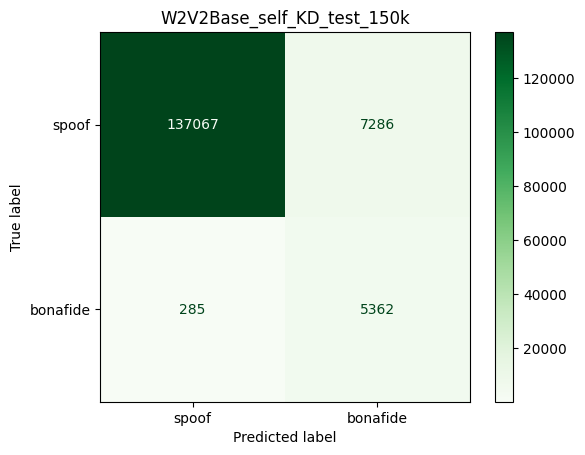

In [6]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate EER
conformer_spoof_scores = res_supcon_conformer_df[res_supcon_conformer_df['label'] == 'spoof']['score']
conformer_bonafide_scores = res_supcon_conformer_df[res_supcon_conformer_df['label'] == 'bonafide']['score']

conf_eer, conf_threshold = compute_eer(conformer_bonafide_scores, conformer_spoof_scores)

print("EER: {:.4f}%, threshold: {:.4f}".format(conf_eer*100, conf_threshold)) # type: ignore

res_supcon_conformer_df['pred'] = res_supcon_conformer_df['score'].apply(lambda x: 'spoof' if x < conf_threshold else 'bonafide')



# confusion matrix for AASIST-SSL
cm = confusion_matrix(res_supcon_conformer_df["label"], res_supcon_conformer_df["pred"], labels=["spoof","bonafide"])  # type: ignore
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])  # type: ignore
disp.plot(cmap='Greens', values_format='g')
plt.title("W2V2Base_self_KD_test_150k")
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.grid(False)
plt.show()
